In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 1. Carregamento das Imagens
# ==========================================
# Substitua pelos caminhos das suas imagens
img1 = cv2.imread('/home/aki/Desktop/GitHub/Python-VO/Datasets/dataset_20260321_120618/stereo_left/1774105585480500149.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/home/aki/Desktop/GitHub/Python-VO/Datasets/dataset_20260321_120618/stereo_left/1774105585715024987.png', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise ValueError("Erro ao carregar as imagens. Verifique os caminhos.")

# ==========================================
# 1.1 Calibração das Imagens (undistort)
# ==========================================
K = np.array([[765.4723, 0.0, 331.6566],
              [0.0, 766.6782, 246.3781],
              [0.0, 0.0, 1.0]], dtype=np.float64)
dist = np.array([0.0844, 0.2218, 0.0, 0.0], dtype=np.float64)

img1 = cv2.undistort(img1, K, dist)
img2 = cv2.undistort(img2, K, dist)

# ==========================================
# 2. Extração de Features e Descritores (SIFT)
# ==========================================
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# ==========================================
# 3. Match de Pontos usando Brute-Force
# ==========================================
# Como usamos SIFT (ponto flutuante), a norma padrão é L2.
bf = cv2.BFMatcher(cv2.NORM_L2)
matches = bf.knnMatch(des1, des2, k=2)

# ==========================================
# 4. Filtro de Matches (Lowe's Ratio Test)
# ==========================================
good_matches = []
pts1 = []
pts2 = []

# O teste de Lowe ajuda a remover falsos positivos
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
        pts1.append(kp1[m.queryIdx].pt)
        pts2.append(kp2[m.trainIdx].pt)

pts1 = np.float32(pts1)
pts2 = np.float32(pts2)

print(f"Total de matches bons encontrados: {len(good_matches)}")


Total de matches bons encontrados: 21


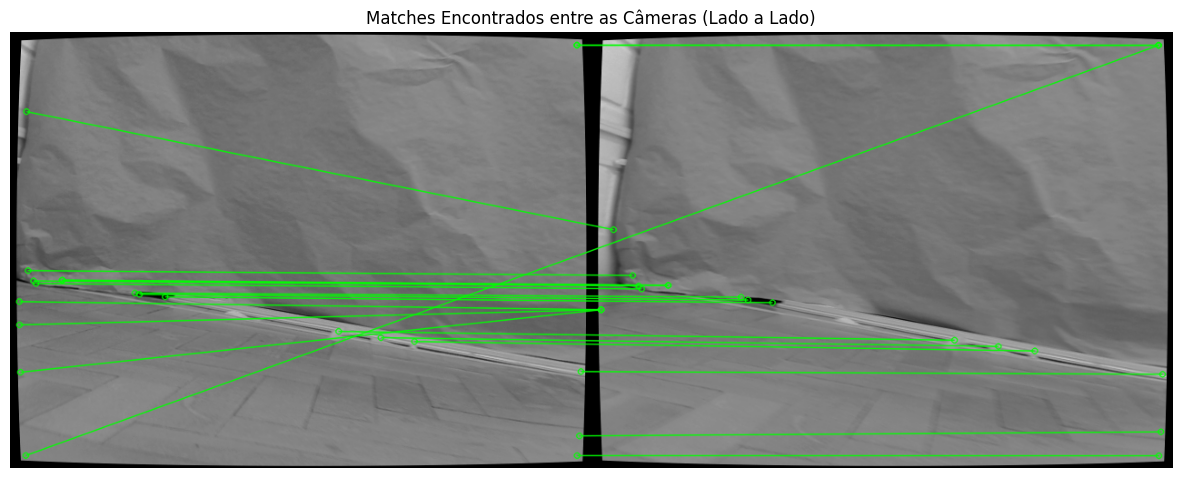

In [3]:
# ==========================================
# 4.1 Visualização dos Matches (Lado a Lado)
# ==========================================
# Vamos desenhar apenas os 100 melhores matches para a imagem não virar um "rabisco" ilegível.
# Se quiser ver todos, basta trocar good_matches[:100] por good_matches
img_matches = cv2.drawMatches(
    img1, kp1, 
    img2, kp2, 
    good_matches[:100], None, 
    matchColor=(0, 255, 0), # Linhas de conexão em verde
    singlePointColor=None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS # Não desenha pontos sem par
)

# Plotar a imagem com Matplotlib
fig_matches = plt.figure(figsize=(15, 6))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB)) # Converte cor para o Matplotlib
plt.title('Matches Encontrados entre as Câmeras (Lado a Lado)')
plt.axis('off') # Esconde os eixos numéricos
plt.show()

In [4]:
# ==========================================
# 5. Parâmetros da Câmera (Intrínsecos e Distorção)
# ==========================================
# Matriz Intrínseca (K) extraída do YAML
K = np.array([[765.4723,      0.0, 331.6566],
              [     0.0, 766.6782, 246.3781],
              [     0.0,      0.0,      1.0]], dtype=np.float64)

# Coeficientes de distorção: [k1, k2, p1, p2]
# Utilizando a array 'data' do seu YAML
dist = np.array([0.0844, 0.2218, 0.0, 0.0], dtype=np.float64)

# ==========================================
# 5.1 Correção de Distorção dos Pontos
# ==========================================
# É fundamental remover a distorção da lente dos pontos encontrados 
# antes de estimar a geometria epipolar (Matriz Essencial).
# O cv2.undistortPoints retorna os pontos normalizados, então multiplicamos por K 
# novamente para voltar ao espaço de pixels da câmera.

pts1_undistorted = cv2.undistortPoints(np.expand_dims(pts1, axis=1), K, dist, P=K)
pts2_undistorted = cv2.undistortPoints(np.expand_dims(pts2, axis=1), K, dist, P=K)

# Removendo a dimensão extra adicionada para a função do OpenCV
pts1_ready = pts1_undistorted.squeeze()
pts2_ready = pts2_undistorted.squeeze()

# ==========================================
# 6. Cálculo da Matriz Essencial e Pose Relativa
# ==========================================
# Agora usamos os pontos corrigidos (pts1_ready e pts2_ready)
E, mask = cv2.findEssentialMat(pts1_ready, pts2_ready, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)

# Filtra apenas os pontos inliers
pts1_inliers = pts1_ready[mask.ravel() == 1]
pts2_inliers = pts2_ready[mask.ravel() == 1]

# Recupera a Rotação (R) e Translação (t)
_, R, t, mask_pose = cv2.recoverPose(E, pts1_inliers, pts2_inliers, K)

# ==========================================
# 7. Construção das Matrizes de Projeção
# ==========================================
# Matriz de projeção da câmera 1: P1 = K[I | 0] (Considerada a origem do mundo)
Rt1 = np.hstack((np.eye(3), np.zeros((3, 1))))
P1 = np.dot(K, Rt1)

# Matriz de projeção da câmera 2: P2 = K[R | t]
Rt2 = np.hstack((R, t))
P2 = np.dot(K, Rt2)



In [30]:
# ==========================================
# 8. Triangulação dos Pontos
# ==========================================
# A função triangulatePoints retorna os pontos em coordenadas homogêneas (4D: X, Y, Z, W)
pontos_4d_hom = cv2.triangulatePoints(P1, P2, pts1.T, pts2.T)

# Converter de coordenadas homogêneas para 3D euclidiano dividindo pelo último elemento (W)
pontos_3d = pontos_4d_hom / pontos_4d_hom[3]
pontos_3d = pontos_3d[:3, :].T # Transpor para ficar no formato (N, 3)

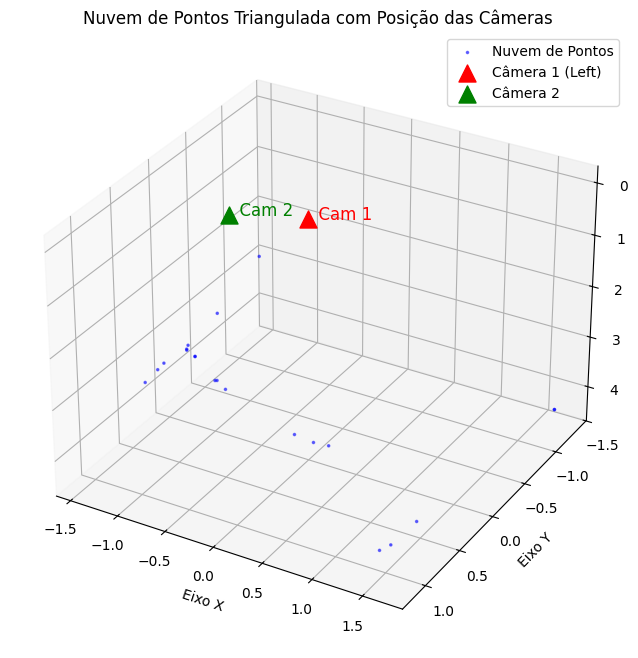

In [31]:
# ==========================================
# 9. Visualização 3D (com as Câmeras)
# ==========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 1. Extraindo X, Y, Z da nuvem de pontos
X = pontos_3d[:, 0]
Y = pontos_3d[:, 1]
Z = pontos_3d[:, 2]

# 2. Plotar a nuvem de pontos
ax.scatter(X, Y, Z, c='b', marker='.', s=10, label='Nuvem de Pontos', alpha=0.5)

# ==========================================
# CÁLCULO E PLOTAGEM DAS CÂMERAS
# ==========================================
# Câmera 1 está na origem
C1 = np.array([0, 0, 0])

# Câmera 2 está em -R^T * t
# R.T é a matriz transposta de R. Usamos flatten() para garantir que seja um vetor 1D
C2 = -np.dot(R.T, t).flatten()

# Plotar Câmera 1 (em Vermelho)
ax.scatter(C1[0], C1[1], C1[2], c='r', marker='^', s=150, label='Câmera 1 (Left)')
ax.text(C1[0], C1[1], C1[2], '  Cam 1', color='red', fontsize=12)

# Plotar Câmera 2 (em Verde)
ax.scatter(C2[0], C2[1], C2[2], c='g', marker='^', s=150, label='Câmera 2')
ax.text(C2[0], C2[1], C2[2], '  Cam 2', color='green', fontsize=12)

# ==========================================
# Configurações do gráfico
# ==========================================
ax.set_xlabel('Eixo X')
ax.set_ylabel('Eixo Y')
ax.set_zlabel('Eixo Z')
ax.set_title('Nuvem de Pontos Triangulada com Posição das Câmeras')

# Adiciona a legenda para identificar o que é câmera e o que é ponto
ax.legend()

# Inverter o eixo Y e Z pode ser necessário dependendo do sistema de coordenadas da câmera vs Matplotlib
ax.invert_yaxis()
ax.invert_zaxis()

# Para evitar que as câmeras distorçam muito a escala do gráfico caso a nuvem de pontos seja muito ampla,
# você pode garantir que os eixos fiquem proporcionais com o comando abaixo (opcional):
# ax.set_box_aspect([1,1,1]) 

plt.show()

In [32]:
import plotly.graph_objects as go

# ==========================================
# 9. Visualização 3D Interativa (Plotly)
# ==========================================


# 1. Criar o objeto para a Nuvem de Pontos
trace_pontos = go.Scatter3d(
    x=X, y=Y, z=Z,
    mode='markers',
    marker=dict(
        size=2,          # Tamanho dos pontos
        color='blue', 
        opacity=0.6      # Leve transparência para ver a densidade
    ),
    name='Nuvem de Pontos'
)

# 2. Criar o objeto para a Câmera 1 (Origem)
trace_cam1 = go.Scatter3d(
    x=[C1[0]], y=[C1[1]], z=[C1[2]],
    mode='markers+text',
    marker=dict(size=8, color='red', symbol='diamond'),
    text=['Cam 1 (Left)'],
    textposition='top center',
    name='Câmera 1'
)

# 3. Criar o objeto para a Câmera 2
trace_cam2 = go.Scatter3d(
    x=[C2[0]], y=[C2[1]], z=[C2[2]],
    mode='markers+text',
    marker=dict(size=8, color='green', symbol='diamond'),
    text=['Cam 2'],
    textposition='top center',
    name='Câmera 2'
)

# 4. Configurar o layout da cena (Eixos e Câmera inicial)
layout = go.Layout(
    title='Nuvem de Pontos Interativa',
    scene=dict(
        xaxis_title='Eixo X',
        yaxis_title='Eixo Y',
        zaxis_title='Eixo Z',
        # Invertendo os eixos para bater com o padrão de visão de câmera (como no Matplotlib)
        yaxis=dict(autorange="reversed"),
        zaxis=dict(autorange="reversed"),
        aspectmode='data' # Mantém a proporção real 1:1:1 dos eixos para não achatar a nuvem
    ),
    margin=dict(l=0, r=0, b=0, t=40) # Margens apertadas para focar no gráfico
)

# 5. Renderizar a figura no Notebook
fig = go.Figure(data=[trace_pontos, trace_cam1, trace_cam2], layout=layout)
fig.show()

In [33]:
import gtsam
import numpy as np

# ==========================================
# 1. Configuração Inicial e Calibração
# ==========================================
# Usando os parâmetros da sua lente (fx, fy, s, cx, cy)
# s = skew (geralmente 0)
K = gtsam.Cal3_S2(765.4723, 766.6782, 0.0, 331.6566, 246.3781)

# Modelos de ruído (Incerteza das medições)
# Se o SIFT erra cerca de 1 pixel, usamos 1.0. 
noise_pixel = gtsam.noiseModel.Isotropic.Sigma(2, 1.0) 
# Ruído muito pequeno para "travar" a primeira câmera na origem (Prior)
noise_prior = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1]))

# Criação do Grafo de Fatores
graph = gtsam.NonlinearFactorGraph()

# ==========================================
# 2. Definição das Variáveis (Keys)
# ==========================================
# No GTSAM, identificamos variáveis por letras (X para Poses, L para Landmarks/Pontos)
# Vamos criar símbolos para Câmera 1, Câmera 2 e três pontos 3D.
def X(i): return gtsam.symbol('x', i)
def L(j): return gtsam.symbol('l', j)

# ==========================================
# 3. Adicionando Fatores (Restrições e Medições)
# ==========================================

# A. Prior Factor: Ancorar a Câmera 1 na origem. 
# Sem isso, o grafo "flutua" no espaço infinito.
pose1_real = gtsam.Pose3(gtsam.Rot3(), gtsam.Point3(0, 0, 0))
graph.add(gtsam.PriorFactorPose3(X(1), pose1_real, noise_prior))

# Dados simulados das medições do SIFT (coordenadas de pixels x, y)
# Na prática, isso viria da sua extração de features
measurements = [
    # (Câmera 1)  Ponto 1          Ponto 2          Ponto 3
    [gtsam.Point2(331.6, 246.3), gtsam.Point2(400.0, 246.3), gtsam.Point2(331.6, 300.0)],
    # (Câmera 2)  Ponto 1          Ponto 2          Ponto 3
    [gtsam.Point2(300.0, 246.3), gtsam.Point2(360.0, 246.3), gtsam.Point2(300.0, 290.0)]
]

# B. Projection Factors: Conectam a pose da câmera e a posição 3D do ponto à medição 2D
for i, camera_measurements in enumerate(measurements):
    camera_idx = i + 1
    for j, pixel in enumerate(camera_measurements):
        landmark_idx = j + 1
        factor = gtsam.GenericProjectionFactorCal3_S2(
            pixel, noise_pixel, X(camera_idx), L(landmark_idx), K
        )
        graph.add(factor)

# ==========================================
# 4. Inserindo as Estimativas Iniciais (O que o RANSAC/Triangulação nos deu)
# ==========================================
# O GTSAM é uma otimização iterativa, ele precisa de um "chute inicial" (sua triangulação atual)
initial_estimates = gtsam.Values()

# Estimativa inicial das câmeras (com um leve erro proposital)
initial_estimates.insert(X(1), gtsam.Pose3(gtsam.Rot3(), gtsam.Point3(0.01, -0.02, 0.05)))
initial_estimates.insert(X(2), gtsam.Pose3(gtsam.Rot3(), gtsam.Point3(1.1, 0.05, -0.1)))

# Estimativa inicial dos pontos 3D (supondo que estavam a Z=5 metros, com erros)
initial_estimates.insert(L(1), gtsam.Point3(0.1, -0.1, 4.8))
initial_estimates.insert(L(2), gtsam.Point3(1.2,  0.2, 5.3))
initial_estimates.insert(L(3), gtsam.Point3(-0.2, 1.1, 4.9))

print("=== Erro Antes da Otimização ===")
print(f"Erro Inicial: {graph.error(initial_estimates):.4f}")

# ==========================================
# 5. Executando o Bundle Adjustment (Otimização)
# ==========================================
# O Levenberg-Marquardt é o algoritmo padrão para problemas de mínimos quadrados não-lineares
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial_estimates)
result = optimizer.optimize()

print("\n=== Erro Após a Otimização ===")
print(f"Erro Final: {graph.error(result):.4f}")

# ==========================================
# 6. Extraindo os Resultados Refinados
# ==========================================
print("\n=== Poses Otimizadas das Câmeras ===")
print(f"Câmera 1:\n{result.atPose3(X(1))}")
print(f"Câmera 2:\n{result.atPose3(X(2))}")

print("\n=== Pontos 3D Otimizados ===")
for j in range(1, 4):
    print(f"Ponto L({j}): {result.atPoint3(L(j))}")

=== Erro Antes da Otimização ===
Erro Inicial: 43656.2012

=== Erro Após a Otimização ===
Erro Final: 0.0000

=== Poses Otimizadas das Câmeras ===
Câmera 1:
R: [
	1, 3.28772e-17, -2.92544e-15;
	-3.8868e-17, 1, -2.32286e-16;
	2.9255e-15, 2.32631e-16, 1
]
t: -5.45312e-16 -3.95748e-17  3.92727e-15

Câmera 2:
R: [
	0.990275, -0.00583333, -0.138999;
	0.00382448, 0.999884, -0.014715;
	0.139069, 0.0140403, 0.990183
]
t:   1.11504 0.0923067   -1.0589


=== Pontos 3D Otimizados ===
Ponto L(1): [-3.72883175e-04 -5.13716785e-04  5.04296364e+00]
Ponto L(2): [ 4.67653747e-01 -5.33574709e-04  5.23790138e+00]
Ponto L(3): [-3.72416993e-04  3.52266725e-01  5.03665887e+00]


In [34]:
import plotly.graph_objects as go
import numpy as np
import gtsam

def plot_otimizacao_antes_depois(valores_iniciais, valores_finais, num_cameras, num_pontos):
    """
    Plota o estado do sistema antes (vermelho) e depois (azul) do Bundle Adjustment.
    
    Parâmetros:
    - valores_iniciais: gtsam.Values com as estimativas antes da otimização
    - valores_finais: gtsam.Values com os resultados após a otimização
    - num_cameras: quantidade de câmeras no grafo
    - num_pontos: quantidade de pontos 3D (landmarks) no grafo
    """
    
    # Recriando as funções de símbolo caso a função seja chamada em outra célula
    def X(i): return gtsam.symbol('x', i)
    def L(j): return gtsam.symbol('l', j)

    fig = go.Figure()

    # ==========================================
    # 1. Extração e Plotagem dos Pontos 3D (Landmarks)
    # ==========================================
    pts_antes = np.array([valores_iniciais.atPoint3(L(i)) for i in range(1, num_pontos + 1)])
    pts_depois = np.array([valores_finais.atPoint3(L(i)) for i in range(1, num_pontos + 1)])

    # Plotar Pontos Antes (Vermelho)
    fig.add_trace(go.Scatter3d(
        x=pts_antes[:, 0], y=pts_antes[:, 1], z=pts_antes[:, 2],
        mode='markers', name='Pontos 3D (Estimativa Inicial)',
        marker=dict(size=4, color='red', opacity=0.5)
    ))

    # Plotar Pontos Depois (Azul)
    fig.add_trace(go.Scatter3d(
        x=pts_depois[:, 0], y=pts_depois[:, 1], z=pts_depois[:, 2],
        mode='markers', name='Pontos 3D (Otimizados)',
        marker=dict(size=5, color='blue', opacity=0.9)
    ))

    # Desenhar linhas conectando o Antes -> Depois dos pontos
    for i in range(num_pontos):
        fig.add_trace(go.Scatter3d(
            x=[pts_antes[i, 0], pts_depois[i, 0]],
            y=[pts_antes[i, 1], pts_depois[i, 1]],
            z=[pts_antes[i, 2], pts_depois[i, 2]],
            mode='lines', showlegend=False,
            line=dict(color='gray', width=2, dash='dot')
        ))

    # ==========================================
    # 2. Extração e Plotagem das Câmeras (Poses)
    # ==========================================
    # Extraímos apenas a translação (posição X, Y, Z) da matriz de Pose
    cams_antes = np.array([valores_iniciais.atPose3(X(i)).translation() for i in range(1, num_cameras + 1)])
    cams_depois = np.array([valores_finais.atPose3(X(i)).translation() for i in range(1, num_cameras + 1)])

    # Nomes das câmeras para o texto flutuante
    textos_cams = [f"Cam {i}" for i in range(1, num_cameras + 1)]

    # Plotar Câmeras Antes (Laranja Escuro)
    fig.add_trace(go.Scatter3d(
        x=cams_antes[:, 0], y=cams_antes[:, 1], z=cams_antes[:, 2],
        mode='markers+text', name='Câmeras (Estimativa Inicial)',
        text=textos_cams, textposition='bottom center',
        marker=dict(size=10, color='darkorange', symbol='diamond', opacity=0.5)
    ))

    # Plotar Câmeras Depois (Verde)
    fig.add_trace(go.Scatter3d(
        x=cams_depois[:, 0], y=cams_depois[:, 1], z=cams_depois[:, 2],
        mode='markers+text', name='Câmeras (Otimizadas)',
        text=textos_cams, textposition='top center',
        marker=dict(size=12, color='green', symbol='diamond', opacity=1.0)
    ))

    # Desenhar linhas conectando o Antes -> Depois das câmeras
    for i in range(num_cameras):
        fig.add_trace(go.Scatter3d(
            x=[cams_antes[i, 0], cams_depois[i, 0]],
            y=[cams_antes[i, 1], cams_depois[i, 1]],
            z=[cams_antes[i, 2], cams_depois[i, 2]],
            mode='lines', showlegend=False,
            line=dict(color='black', width=3, dash='solid')
        ))

    # ==========================================
    # 3. Configurações de Layout
    # ==========================================
    fig.update_layout(
        title='Bundle Adjustment: Antes (Vermelho/Laranja) vs Depois (Azul/Verde)',
        scene=dict(
            xaxis_title='Eixo X',
            yaxis_title='Eixo Y',
            zaxis_title='Eixo Z',
            # Mantemos a proporção 1:1:1 para não distorcer a geometria real
            aspectmode='data' 
        ),
        legend=dict(x=0, y=1, bgcolor='rgba(255,255,255,0.7)'),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

# ==========================================
# Como chamar a função no seu código:
# ==========================================
# Considerando que você já rodou o otimizador do código anterior:
# optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial_estimates)
# result = optimizer.optimize()

plot_otimizacao_antes_depois(
    valores_iniciais=initial_estimates, 
    valores_finais=result, 
    num_cameras=2,   # Temos a Câmera 1 e Câmera 2
    num_pontos=3     # Criamos 3 pontos 3D no exemplo
)

In [ ]:
import cv2
import numpy as np
import plotly.graph_objects as go
import glob

# GTSAM imports
import gtsam
from gtsam import (
    ISAM2,
    ISAM2Params,
    NonlinearFactorGraph,
    Values,
    Pose3,
    Point3,
    Rot3,
    Cal3_S2,
    noiseModel,
    symbol_shorthand,
)
from gtsam.symbol_shorthand import X, L  # X = camera poses, L = landmarks


class VisualOdometryGTSAM:
    """
    Monocular Visual Odometry with GTSAM iSAM2 back-end.

    Pipeline per frame:
        1. Feature detection (SIFT) + matching
        2. Pose estimation (Essential Matrix for frame 1, PnP for frames 2+)
        3. Triangulation of new 3-D landmarks
        4. Build GTSAM factor graph:
             - Prior on pose 0 (anchor)
             - BetweenFactor on consecutive poses (odometry)
             - GenericProjectionFactor for every 2-D observation
        5. iSAM2 incremental optimisation
        6. Pull refined poses/landmarks back into the VO state
    """

    # ------------------------------------------------------------------ #
    #  Construction                                                        #
    # ------------------------------------------------------------------ #

    def __init__(self, K: np.ndarray, dist: np.ndarray):
        self.K_np   = K
        self.dist   = dist

        # GTSAM calibration object (fx, fy, s, cx, cy)
        fx, fy = K[0, 0], K[1, 1]
        cx, cy = K[0, 2], K[1, 2]
        s      = K[0, 1]
        self.K_gtsam = Cal3_S2(fx, fy, s, cx, cy)

        # ---- OpenCV feature tools ----
        self.sift = cv2.SIFT_create()
        self.bf   = cv2.BFMatcher(cv2.NORM_L2)

        # ---- GTSAM iSAM2 ----
        isam_params = ISAM2Params()
        isam_params.setRelinearizeThreshold(0.1)
        isam_params.relinearizeSkip = 1
        self.isam        = ISAM2(isam_params)
        self.new_factors = NonlinearFactorGraph()   # accumulates between updates
        self.new_values  = Values()                 # initial guesses

        # ---- Noise models ----
        # Reprojection noise: 1.5 px std-dev
        self.proj_noise = noiseModel.Isotropic.Sigma(2, 1.5)
        # Prior on pose 0
        self.prior_noise = noiseModel.Diagonal.Sigmas(
            np.array([1e-6, 1e-6, 1e-6, 1e-6, 1e-6, 1e-6])
        )
        # Between-pose odometry (rotation rad, translation m)
        self.odom_noise = noiseModel.Diagonal.Sigmas(
            np.array([0.01, 0.01, 0.01, 0.05, 0.05, 0.05])
        )

        # ---- VO state ----
        self.frame_idx      = 0
        self.landmark_count = 0          # running landmark id counter

        # pose_list[i]  = gtsam.Pose3 for camera i (updated after each iSAM2 solve)
        self.pose_list: list[Pose3] = []
        # map_pts[j]    = np.array([X, Y, Z])  (world coords, updated after solve)
        self.map_pts: list[np.ndarray]  = []
        # map_desc[j]   = SIFT descriptor (128-d float32 row)
        self.map_desc: list[np.ndarray] = []
        # lm_symbol[j]  = GTSAM symbol key for landmark j
        self.lm_symbol: list[int]       = []

        # Previous-frame bookkeeping
        self.kp_prev:   list | None = None
        self.des_prev:  np.ndarray | None = None
        self.pose_prev: Pose3 | None = None

    # ------------------------------------------------------------------ #
    #  Helpers                                                             #
    # ------------------------------------------------------------------ #

    def _load_undistort(self, path: str) -> np.ndarray:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Não foi possível carregar: {path}")
        return cv2.undistort(img, self.K_np, self.dist)

    @staticmethod
    def _pose3_from_Rt(R: np.ndarray, t: np.ndarray) -> Pose3:
        """Build a GTSAM Pose3 from an OpenCV R (3×3) and t (3×1) array.

        OpenCV convention:  p_cam = R * p_world + t
        GTSAM Pose3:        camera position in world = -R^T * t
        """
        rot = Rot3(R)
        # camera centre in world coordinates
        C = -R.T @ t.flatten()
        return Pose3(rot, Point3(C))

    @staticmethod
    def _cam_position(pose: Pose3) -> np.ndarray:
        return pose.translation()   # already the camera centre

    def _match_knn(self, des_query: np.ndarray, des_train: np.ndarray,
                   ratio: float = 0.75):
        """Lowe ratio-test matches. Returns (idx_query, idx_train)."""
        matches = self.bf.knnMatch(des_query, des_train, k=2)
        good_q, good_t = [], []
        for m, n in matches:
            if m.distance < ratio * n.distance:
                good_q.append(m.queryIdx)
                good_t.append(m.trainIdx)
        return np.array(good_q, dtype=int), np.array(good_t, dtype=int)

    def _triangulate(self, P0: np.ndarray, P1: np.ndarray,
                     pts0: np.ndarray, pts1: np.ndarray) -> np.ndarray:
        """Triangulate and return Nx3 points."""
        pts4d = cv2.triangulatePoints(P0, P1, pts0.T, pts1.T)
        pts3d = (pts4d[:3] / pts4d[3]).T
        return pts3d

    def _proj_matrix(self, pose: Pose3) -> np.ndarray:
        """Return 3×4 projection matrix P = K [R | t] from a GTSAM Pose3."""
        R = pose.rotation().matrix()
        t = pose.translation()
        # p_cam = R^T * (p_world - C)  =>  t_cv = -R * C
        t_cv = -R @ t
        Rt = np.hstack([R, t_cv.reshape(3, 1)])
        return self.K_np @ Rt

    def _add_projection_factor(self, pose_sym: int, lm_sym: int,
                               pt2d: np.ndarray):
        """Add a GenericProjectionFactorCal3_S2 to the pending graph."""
        measured = gtsam.Point2(pt2d[0], pt2d[1])
        factor = gtsam.GenericProjectionFactorCal3_S2(
            measured,
            self.proj_noise,
            pose_sym,
            lm_sym,
            self.K_gtsam,
        )
        self.new_factors.push_back(factor)

    def _isam_update_and_sync(self):
        """Push pending factors/values to iSAM2 and read back refined state."""
        print(self.new_factors)
        self.isam.update(self.new_factors, self.new_values)
        # Extra iteration for convergence
        self.isam.update()

        result = self.isam.calculateEstimate()

        # Reset accumulators
        self.new_factors = NonlinearFactorGraph()
        self.new_values  = Values()

        # Sync camera poses
        for i in range(len(self.pose_list)):
            if result.exists(X(i)):
                self.pose_list[i] = result.atPose3(X(i))

        # Sync landmark positions
        for j in range(len(self.lm_symbol)):
            sym = self.lm_symbol[j]
            if result.exists(sym):
                self.map_pts[j] = np.array(result.atPoint3(sym))

        # Update prev_pose to the latest refined pose
        if self.pose_list:
            self.pose_prev = self.pose_list[-1]

    # ------------------------------------------------------------------ #
    #  Frame processing                                                    #
    # ------------------------------------------------------------------ #

    def processar_primeiro_frame(self, img_path: str):
        img = self._load_undistort(img_path)
        self.kp_prev, self.des_prev = self.sift.detectAndCompute(img, None)

        pose0 = Pose3()          # identity – world origin
        self.pose_list.append(pose0)
        self.pose_prev = pose0

        # ---- GTSAM: add prior on pose 0 ----
        self.new_factors.addPriorPose3(X(0), pose0, self.prior_noise)
        self.new_values.insert(X(0), pose0)

        self.isam.update(self.new_factors, self.new_values)
        self.new_factors = NonlinearFactorGraph()
        self.new_values  = Values()

        self.frame_idx = 1
        print("Frame 0 processado – origem definida.")

    def processar_segundo_frame(self, img_path: str):
        img = self._load_undistort(img_path)
        kp_curr, des_curr = self.sift.detectAndCompute(img, None)

        # ---- Match ----
        q_idx, t_idx = self._match_knn(self.des_prev, des_curr)
        pts0 = np.float32([self.kp_prev[i].pt for i in q_idx])
        pts1 = np.float32([kp_curr[i].pt for i in t_idx])

        # ---- Essential Matrix ----
        E, mask = cv2.findEssentialMat(
            pts0, pts1, self.K_np, method=cv2.RANSAC, prob=0.999, threshold=1.0
        )
        mask = mask.ravel().astype(bool)
        pts0_in, pts1_in = pts0[mask], pts1[mask]
        q_idx_in, t_idx_in = q_idx[mask], t_idx[mask]

        _, R_cv, t_cv, _ = cv2.recoverPose(E, pts0_in, pts1_in, self.K_np)

        pose1 = self._pose3_from_Rt(R_cv, t_cv)
        self.pose_list.append(pose1)

        # ---- Triangulate ----
        P0 = self._proj_matrix(self.pose_list[0])
        P1 = self._proj_matrix(pose1)
        pts3d = self._triangulate(P0, P1, pts0_in, pts1_in)

        # ---- GTSAM: add pose 1 + odometry + projection factors ----
        # Between-pose (odometry)
        rel_pose = self.pose_list[0].between(pose1)
        self.new_factors.add(
            gtsam.BetweenFactorPose3(X(0), X(1), rel_pose, self.odom_noise)
        )
        self.new_values.insert(X(1), pose1)

        # Landmark factors
        for k, pt3d in enumerate(pts3d):
            sym = L(self.landmark_count)
            self.lm_symbol.append(sym)
            self.map_pts.append(pt3d.copy())
            self.map_desc.append(des_curr[t_idx_in[k]].copy())

            self.new_values.insert(sym, Point3(pt3d))
            self._add_projection_factor(X(0), sym, pts0_in[k])
            self._add_projection_factor(X(1), sym, pts1_in[k])

            self.landmark_count += 1

        self._isam_update_and_sync()

        self.kp_prev  = kp_curr
        self.des_prev = des_curr
        self.frame_idx = 2
        print(f"Frame 1 processado – {len(pts3d)} landmarks inicializados.")

    def processar_frame(self, img_path: str):
        i = self.frame_idx
        img = self._load_undistort(img_path)
        kp_curr, des_curr = self.sift.detectAndCompute(img, None)

        if len(self.map_desc) == 0:
            print(f"Frame {i}: mapa vazio, pulando."); return

        # ---- Match current frame against global map ----
        map_desc_arr  = np.vstack(self.map_desc)   # (M, 128)
        q_idx, t_idx  = self._match_knn(map_desc_arr, des_curr)

        if len(q_idx) < 10:
            print(f"Frame {i}: muito poucos matches ({len(q_idx)}), pulando."); return

        pts3d_known = np.float32([self.map_pts[j] for j in q_idx])
        pts2d_curr  = np.float32([kp_curr[j].pt   for j in t_idx])

        # ---- PnP ----
        success, rvec, tvec, inliers = cv2.solvePnPRansac(
            pts3d_known, pts2d_curr, self.K_np, np.zeros(4),
            iterationsCount=200, reprojectionError=2.0, confidence=0.999
        )
        if not success or inliers is None:
            print(f"Frame {i}: PnP falhou."); return

        inliers = inliers.flatten()
        R_cv, _ = cv2.Rodrigues(rvec)
        pose_i   = self._pose3_from_Rt(R_cv, tvec)
        self.pose_list.append(pose_i)

        # ---- GTSAM: odometry + projection factors for PnP inliers ----
        rel_pose = self.pose_prev.between(pose_i)
        self.new_factors.add(
            gtsam.BetweenFactorPose3(X(i - 1), X(i), rel_pose, self.odom_noise)
        )
        self.new_values.insert(X(i), pose_i)

        for idx in inliers:
            lm_j = q_idx[idx]
            self._add_projection_factor(X(i), self.lm_symbol[lm_j], pts2d_curr[idx])

        # ---- Triangulate NEW points (frame i-1 → frame i) ----
        # Use only the current frame's features not already in the map
        in_map_set = set(q_idx[inliers].tolist())

        # Match prev frame → current frame
        q2_idx, t2_idx = self._match_knn(self.des_prev, des_curr)
        new_q2, new_t2 = [], []
        for qi, ti in zip(q2_idx, t2_idx):
            if ti not in in_map_set:
                new_q2.append(qi)
                new_t2.append(ti)

        if len(new_q2) >= 8:
            pts_prev_new = np.float32([self.kp_prev[j].pt for j in new_q2])
            pts_curr_new = np.float32([kp_curr[j].pt      for j in new_t2])
            P_prev = self._proj_matrix(self.pose_prev)
            P_curr = self._proj_matrix(pose_i)
            new_3d = self._triangulate(P_prev, P_curr, pts_prev_new, pts_curr_new)

            # Basic cheirality filter: keep points in front of both cameras
            good_mask = new_3d[:, 2] > 0
            new_3d   = new_3d[good_mask]
            new_t2f  = np.array(new_t2)[good_mask]

            for k, pt3d in enumerate(new_3d):
                sym = L(self.landmark_count)
                self.lm_symbol.append(sym)
                self.map_pts.append(pt3d.copy())
                self.map_desc.append(des_curr[new_t2f[k]].copy())

                self.new_values.insert(sym, Point3(pt3d))
                self._add_projection_factor(X(i), sym,
                                            kp_curr[new_t2f[k]].pt)
                self.landmark_count += 1

        self._isam_update_and_sync()

        self.kp_prev  = kp_curr
        self.des_prev = des_curr
        self.frame_idx += 1
        print(f"Frame {i} processado via PnP+GTSAM. "
              f"Mapa: {len(self.map_pts)} pontos.")

    # ------------------------------------------------------------------ #
    #  Visualisation                                                       #
    # ------------------------------------------------------------------ #

    def plotar_trajetoria_e_mapa(self):
        cams = np.array([self._cam_position(p) for p in self.pose_list])
        mapa = np.array(self.map_pts)

        fig = go.Figure()

        # --- 3-D point cloud (remove distant outliers for a clean plot) ---
        if mapa.shape[0] > 0:
            dist_from_origin = np.linalg.norm(mapa, axis=1)
            threshold        = np.percentile(dist_from_origin, 95)
            mapa_clean       = mapa[dist_from_origin < threshold]
            fig.add_trace(go.Scatter3d(
                x=mapa_clean[:, 0], y=mapa_clean[:, 1], z=mapa_clean[:, 2],
                mode="markers",
                marker=dict(size=2, color="gray", opacity=0.4),
                name="Mapa 3D (GTSAM)"
            ))

        # --- Camera trajectory ---
        fig.add_trace(go.Scatter3d(
            x=cams[:, 0], y=cams[:, 1], z=cams[:, 2],
            mode="lines+markers",
            marker=dict(size=5, color="red"),
            line=dict(color="blue", width=4),
            name="Trajetória (GTSAM)"
        ))

        fig.update_layout(
            title="Odometria Visual com GTSAM – Trajetória e Nuvem de Pontos",
            scene=dict(
                xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
                yaxis=dict(autorange="reversed"),
                zaxis=dict(autorange="reversed"),
                aspectmode="data",
            ),
            margin=dict(l=0, r=0, b=0, t=40),
        )
        fig.show()


# ============================================================
# EXECUÇÃO DO PIPELINE
# ============================================================
if __name__ == "__main__":
    # 1. Parâmetros intrínsecos da câmera
    K = np.array([[765.4723, 0.0,      331.6566],
                  [0.0,      766.6782, 246.3781],
                  [0.0,      0.0,      1.0     ]], dtype=np.float64)

    dist = np.array([0.0844, 0.2218, 0.0, 0.0], dtype=np.float64)

    # 2. Lista de imagens (ajuste o caminho)
    imagens = sorted(glob.glob(
        "/home/aki/Desktop/GitHub/Python-VO/Datasets/"
        "dataset_20260321_120618/stereo_test/*.png"
    ))

    if len(imagens) < 2:
        print("Erro: forneça pelo menos 2 imagens na pasta.")
    else:
        # 3. Inicializar
        vo = VisualOdometryGTSAM(K, dist)

        # 4. Loop de frames
        for i, img_path in enumerate(imagens):
            if i == 0:
                vo.processar_primeiro_frame(img_path)
            elif i == 1:
                vo.processar_segundo_frame(img_path)
            else:
                vo.processar_frame(img_path)

        # 5. Visualizar
        vo.plotar_trajetoria_e_mapa()

Frame 0 processado – origem definida.
Frame 1 processado – 394 landmarks inicializados.


RuntimeError: 
Indeterminant linear system detected while working near variable
7782220156096217190 (Symbol: l102).

Thrown when a linear system is ill-posed.  The most common cause for this
error is having underconstrained variables.  Mathematically, the system is
underdetermined.  See the GTSAM Doxygen documentation at
http://borg.cc.gatech.edu/ on gtsam::IndeterminantLinearSystemException for
more information.

In [1]:
import cv2
import numpy as np
import plotly.graph_objects as go
import glob

# GTSAM imports
import gtsam
from gtsam import (
    ISAM2,
    ISAM2Params,
    NonlinearFactorGraph,
    Values,
    Pose3,
    Point3,
    Rot3,
    Cal3_S2,
    noiseModel,
    symbol_shorthand,
)
from gtsam.symbol_shorthand import X, L  # X = camera poses, L = landmarks


class VisualOdometryGTSAM:
    """
    Monocular Visual Odometry with GTSAM iSAM2 back-end.

    Pipeline per frame:
        1. Feature detection (SIFT) + matching
        2. Pose estimation (Essential Matrix for frame 1, PnP for frames 2+)
        3. Triangulation of new 3-D landmarks
        4. Build GTSAM factor graph:
             - Prior on pose 0 (anchor)
             - BetweenFactor on consecutive poses (odometry)
             - GenericProjectionFactor for every 2-D observation
        5. iSAM2 incremental optimisation
        6. Pull refined poses/landmarks back into the VO state
    """

    # ------------------------------------------------------------------ #
    #  Construction                                                        #
    # ------------------------------------------------------------------ #

    def __init__(self, K: np.ndarray, dist: np.ndarray):
        self.K_np   = K
        self.dist   = dist

        # GTSAM calibration object (fx, fy, s, cx, cy)
        fx, fy = K[0, 0], K[1, 1]
        cx, cy = K[0, 2], K[1, 2]
        s      = K[0, 1]
        self.K_gtsam = Cal3_S2(fx, fy, s, cx, cy)

        # ---- OpenCV feature tools ----
        self.sift = cv2.SIFT_create()
        self.bf   = cv2.BFMatcher(cv2.NORM_L2)

        # ---- GTSAM iSAM2 ----
        isam_params = ISAM2Params()
        isam_params.setRelinearizeThreshold(0.1)
        isam_params.relinearizeSkip = 1
        self.isam        = ISAM2(isam_params)
        self.new_factors = NonlinearFactorGraph()   # accumulates between updates
        self.new_values  = Values()                 # initial guesses

        # ---- Noise models ----
        # Reprojection noise: 1.5 px std-dev
        self.proj_noise = noiseModel.Isotropic.Sigma(2, 1.5)
        # Prior on pose 0
        self.prior_noise = noiseModel.Diagonal.Sigmas(
            np.array([1e-6, 1e-6, 1e-6, 1e-6, 1e-6, 1e-6])
        )
        # Between-pose odometry (rotation rad, translation m)
        self.odom_noise = noiseModel.Diagonal.Sigmas(
            np.array([0.01, 0.01, 0.01, 0.05, 0.05, 0.05])
        )

        # ---- VO state ----
        self.frame_idx      = 0
        self.landmark_count = 0          # running landmark id counter

        # pose_list[i]  = gtsam.Pose3 for camera i (updated after each iSAM2 solve)
        self.pose_list: list[Pose3] = []

        # map_pts[j]    = np.array([X, Y, Z])  (world coords, updated after solve)
        self.map_pts: list[np.ndarray]  = []
        # map_desc[j]   = SIFT descriptor (128-d float32 row)
        self.map_desc: list[np.ndarray] = []
        # lm_symbol[j]  = GTSAM symbol key for landmark j
        self.lm_symbol: list[int]       = []

        # Previous-frame bookkeeping
        self.kp_prev:   list | None = None
        self.des_prev:  np.ndarray | None = None
        self.pose_prev: Pose3 | None = None

        # ---- Store previous keypoints (by index) for triangulation ----
        # We need the previous frame's 2-D points to add the second
        # projection factor when a landmark is first triangulated.
        self.kp_prev_pts: np.ndarray | None = None   # (N, 2) float32

    # ------------------------------------------------------------------ #
    #  Helpers                                                             #
    # ------------------------------------------------------------------ #

    def _load_undistort(self, path: str) -> np.ndarray:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Não foi possível carregar: {path}")
        return cv2.undistort(img, self.K_np, self.dist)

    @staticmethod
    def _pose3_from_Rt(R: np.ndarray, t: np.ndarray) -> Pose3:
        """Build a GTSAM Pose3 from an OpenCV R (3×3) and t (3×1) array.

        OpenCV convention:  p_cam = R * p_world + t
        GTSAM Pose3:        camera position in world = -R^T * t
        """
        rot = Rot3(R)
        # camera centre in world coordinates
        C = -R.T @ t.flatten()
        return Pose3(rot, Point3(C))

    @staticmethod
    def _cam_position(pose: Pose3) -> np.ndarray:
        return pose.translation()   # already the camera centre

    def _match_knn(self, des_query: np.ndarray, des_train: np.ndarray,
                   ratio: float = 0.75):
        """Lowe ratio-test matches. Returns (idx_query, idx_train)."""
        matches = self.bf.knnMatch(des_query, des_train, k=2)
        good_q, good_t = [], []
        for m, n in matches:
            if m.distance < ratio * n.distance:
                good_q.append(m.queryIdx)
                good_t.append(m.trainIdx)
        return np.array(good_q, dtype=int), np.array(good_t, dtype=int)

    def _triangulate(self, P0: np.ndarray, P1: np.ndarray,
                     pts0: np.ndarray, pts1: np.ndarray) -> np.ndarray:
        """Triangulate and return Nx3 points."""
        pts4d = cv2.triangulatePoints(P0, P1, pts0.T, pts1.T)
        pts3d = (pts4d[:3] / pts4d[3]).T
        return pts3d

    def _proj_matrix(self, pose: Pose3) -> np.ndarray:
        """Return 3×4 projection matrix P = K [R | t] from a GTSAM Pose3."""
        R = pose.rotation().matrix()
        t = pose.translation()
        # p_cam = R^T * (p_world - C)  =>  t_cv = -R * C
        t_cv = -R @ t
        Rt = np.hstack([R, t_cv.reshape(3, 1)])
        return self.K_np @ Rt

    def _add_projection_factor(self, pose_sym: int, lm_sym: int,
                               pt2d: np.ndarray):
        """Add a GenericProjectionFactorCal3_S2 to the pending graph."""
        measured = gtsam.Point2(pt2d[0], pt2d[1])
        factor = gtsam.GenericProjectionFactorCal3_S2(
            measured,
            self.proj_noise,
            pose_sym,
            lm_sym,
            self.K_gtsam,
        )
        self.new_factors.push_back(factor)

    # FIX 3: Robust point filter — depth range + reprojection error
    def _filter_triangulated(self, pts3d: np.ndarray,
                              P0: np.ndarray, P1: np.ndarray,
                              pts2d_0: np.ndarray, pts2d_1: np.ndarray,
                              z_min: float = 0.1,
                              z_max: float = 200.0,
                              max_reproj_err: float = 4.0) -> np.ndarray:
        """Return boolean mask of geometrically valid triangulated points."""
        n = pts3d.shape[0]
        mask = np.ones(n, dtype=bool)

        for k in range(n):
            X_h = np.append(pts3d[k], 1.0)

            # Depth in both cameras (z component of P * X)
            z0 = (P0[2] @ X_h)
            z1 = (P1[2] @ X_h)
            if not (z_min < z0 < z_max and z_min < z1 < z_max):
                mask[k] = False
                continue

            # Reprojection error in camera 0
            p0_h = P0 @ X_h
            p0   = p0_h[:2] / p0_h[2]
            err0 = np.linalg.norm(p0 - pts2d_0[k])

            # Reprojection error in camera 1
            p1_h = P1 @ X_h
            p1   = p1_h[:2] / p1_h[2]
            err1 = np.linalg.norm(p1 - pts2d_1[k])

            if err0 > max_reproj_err or err1 > max_reproj_err:
                mask[k] = False

        return mask

    def _isam_update_and_sync(self):
        """Push pending factors/values to iSAM2 and read back refined state."""
        self.isam.update(self.new_factors, self.new_values)
        # Extra iteration for convergence
        self.isam.update()

        result = self.isam.calculateEstimate()

        # Reset accumulators
        self.new_factors = NonlinearFactorGraph()
        self.new_values  = Values()

        # Sync camera poses
        for i in range(len(self.pose_list)):
            if result.exists(X(i)):
                self.pose_list[i] = result.atPose3(X(i))

        # Sync landmark positions
        for j in range(len(self.lm_symbol)):
            sym = self.lm_symbol[j]
            if result.exists(sym):
                self.map_pts[j] = np.array(result.atPoint3(sym))

        # Update prev_pose to the latest refined pose
        if self.pose_list:
            self.pose_prev = self.pose_list[-1]

    # ------------------------------------------------------------------ #
    #  Frame processing                                                    #
    # ------------------------------------------------------------------ #

    def processar_primeiro_frame(self, img_path: str):
        img = self._load_undistort(img_path)
        kp, des = self.sift.detectAndCompute(img, None)
        self.kp_prev  = kp
        self.des_prev = des
        # Store 2-D coordinates for the previous frame
        self.kp_prev_pts = np.float32([k.pt for k in kp])

        pose0 = Pose3()          # identity – world origin
        self.pose_list.append(pose0)
        self.pose_prev = pose0

        # ---- GTSAM: add prior on pose 0 ----
        self.new_factors.addPriorPose3(X(0), pose0, self.prior_noise)
        self.new_values.insert(X(0), pose0)

        self.isam.update(self.new_factors, self.new_values)
        self.new_factors = NonlinearFactorGraph()
        self.new_values  = Values()

        self.frame_idx = 1
        print("Frame 0 processado – origem definida.")

    def processar_segundo_frame(self, img_path: str):
        img = self._load_undistort(img_path)
        kp_curr, des_curr = self.sift.detectAndCompute(img, None)

        # ---- Match ----
        q_idx, t_idx = self._match_knn(self.des_prev, des_curr)
        pts0 = np.float32([self.kp_prev[i].pt for i in q_idx])
        pts1 = np.float32([kp_curr[i].pt for i in t_idx])

        # ---- Essential Matrix ----
        E, mask = cv2.findEssentialMat(
            pts0, pts1, self.K_np, method=cv2.RANSAC, prob=0.999, threshold=1.0
        )
        mask = mask.ravel().astype(bool)
        pts0_in, pts1_in = pts0[mask], pts1[mask]
        q_idx_in, t_idx_in = q_idx[mask], t_idx[mask]

        _, R_cv, t_cv, _ = cv2.recoverPose(E, pts0_in, pts1_in, self.K_np)

        pose1 = self._pose3_from_Rt(R_cv, t_cv)
        self.pose_list.append(pose1)

        # ---- Triangulate ----
        P0 = self._proj_matrix(self.pose_list[0])
        P1 = self._proj_matrix(pose1)
        pts3d = self._triangulate(P0, P1, pts0_in, pts1_in)

        # FIX 3: robust geometric filter before inserting into GTSAM
        good = self._filter_triangulated(pts3d, P0, P1, pts0_in, pts1_in)
        pts3d    = pts3d[good]
        pts0_in  = pts0_in[good]
        pts1_in  = pts1_in[good]
        t_idx_in = t_idx_in[good]

        # ---- GTSAM: add pose 1 + odometry + projection factors ----
        rel_pose = self.pose_list[0].between(pose1)
        self.new_factors.add(
            gtsam.BetweenFactorPose3(X(0), X(1), rel_pose, self.odom_noise)
        )
        self.new_values.insert(X(1), pose1)

        # Landmark factors
        for k, pt3d in enumerate(pts3d):
            sym = L(self.landmark_count)
            self.lm_symbol.append(sym)
            self.map_pts.append(pt3d.copy())
            self.map_desc.append(des_curr[t_idx_in[k]].copy())

            self.new_values.insert(sym, Point3(pt3d))
            # Two observations → fully constrained in 3-D
            self._add_projection_factor(X(0), sym, pts0_in[k])
            self._add_projection_factor(X(1), sym, pts1_in[k])

            self.landmark_count += 1

        self._isam_update_and_sync()

        self.kp_prev      = kp_curr
        self.des_prev     = des_curr
        self.kp_prev_pts  = np.float32([k.pt for k in kp_curr])
        self.frame_idx    = 2
        print(f"Frame 1 processado – {len(pts3d)} landmarks inicializados.")

    def processar_frame(self, img_path: str):
        i = self.frame_idx
        img = self._load_undistort(img_path)
        kp_curr, des_curr = self.sift.detectAndCompute(img, None)

        if len(self.map_desc) == 0:
            print(f"Frame {i}: mapa vazio, pulando.")
            return

        # ---- Match current frame against global map ----
        map_desc_arr = np.vstack(self.map_desc)   # (M, 128)
        # q_idx → indices into map_desc (= landmark indices in self.map_pts)
        # t_idx → indices into kp_curr / des_curr
        q_idx, t_idx = self._match_knn(map_desc_arr, des_curr)

        if len(q_idx) < 10:
            print(f"Frame {i}: muito poucos matches ({len(q_idx)}), pulando.")
            return

        pts3d_known = np.float32([self.map_pts[j] for j in q_idx])
        pts2d_curr  = np.float32([kp_curr[j].pt   for j in t_idx])

        # ---- PnP ----
        success, rvec, tvec, inliers = cv2.solvePnPRansac(
            pts3d_known, pts2d_curr, self.K_np, np.zeros(4),
            iterationsCount=200, reprojectionError=2.0, confidence=0.999
        )
        if not success or inliers is None:
            print(f"Frame {i}: PnP falhou.")
            return

        inliers = inliers.flatten()
        R_cv, _ = cv2.Rodrigues(rvec)
        pose_i   = self._pose3_from_Rt(R_cv, tvec)
        self.pose_list.append(pose_i)

        # ---- GTSAM: odometry + projection factors for PnP inliers ----
        rel_pose = self.pose_prev.between(pose_i)
        self.new_factors.add(
            gtsam.BetweenFactorPose3(X(i - 1), X(i), rel_pose, self.odom_noise)
        )
        self.new_values.insert(X(i), pose_i)

        for idx in inliers:
            lm_j = q_idx[idx]
            self._add_projection_factor(X(i), self.lm_symbol[lm_j], pts2d_curr[idx])

        # ---- Triangulate NEW points (frame i-1 → frame i) ----
        # FIX 2: track which *current-frame keypoint indices* are already mapped
        # t_idx[inliers] gives current-frame kp indices that are in the map.
        already_in_map_curr = set(t_idx[inliers].tolist())

        # Match prev frame → current frame
        q2_idx, t2_idx = self._match_knn(self.des_prev, des_curr)

        # Keep only matches whose current-frame keypoint is NOT yet in the map
        new_mask = np.array([ti not in already_in_map_curr for ti in t2_idx])
        new_q2 = q2_idx[new_mask]
        new_t2 = t2_idx[new_mask]

        if len(new_q2) >= 8:
            pts_prev_new = np.float32([self.kp_prev[j].pt for j in new_q2])
            pts_curr_new = np.float32([kp_curr[j].pt      for j in new_t2])
            P_prev = self._proj_matrix(self.pose_prev)
            P_curr = self._proj_matrix(pose_i)
            new_3d = self._triangulate(P_prev, P_curr, pts_prev_new, pts_curr_new)

            # FIX 3: robust geometric filter
            good = self._filter_triangulated(
                new_3d, P_prev, P_curr, pts_prev_new, pts_curr_new
            )
            new_3d       = new_3d[good]
            pts_prev_new = pts_prev_new[good]
            pts_curr_new = pts_curr_new[good]
            # FIX 4: ensure integer dtype after boolean indexing
            new_t2_good = new_t2[good].astype(int)
            new_q2_good = new_q2[good].astype(int)

            for k, pt3d in enumerate(new_3d):
                sym = L(self.landmark_count)
                self.lm_symbol.append(sym)
                self.map_pts.append(pt3d.copy())
                self.map_desc.append(des_curr[new_t2_good[k]].copy())

                self.new_values.insert(sym, Point3(pt3d))

                # FIX 1: add projection factor for BOTH frames that see this point.
                # Without the previous-frame factor the landmark has only 1
                # constraint and is underdetermined → IndeterminantLinearSystem.
                self._add_projection_factor(
                    X(i - 1), sym, pts_prev_new[k]   # ← the missing factor
                )
                self._add_projection_factor(
                    X(i), sym, pts_curr_new[k]
                )

                self.landmark_count += 1

        self._isam_update_and_sync()

        self.kp_prev      = kp_curr
        self.des_prev     = des_curr
        self.kp_prev_pts  = np.float32([k.pt for k in kp_curr])
        self.frame_idx   += 1
        print(f"Frame {i} processado via PnP+GTSAM. "
              f"Mapa: {len(self.map_pts)} pontos.")

    # ------------------------------------------------------------------ #
    #  Visualisation                                                       #
    # ------------------------------------------------------------------ #

    def plotar_trajetoria_e_mapa(self):
        cams = np.array([self._cam_position(p) for p in self.pose_list])
        mapa = np.array(self.map_pts)

        fig = go.Figure()

        # --- 3-D point cloud (remove distant outliers for a clean plot) ---
        if mapa.shape[0] > 0:
            dist_from_origin = np.linalg.norm(mapa, axis=1)
            threshold        = np.percentile(dist_from_origin, 95)
            mapa_clean       = mapa[dist_from_origin < threshold]
            fig.add_trace(go.Scatter3d(
                x=mapa_clean[:, 0], y=mapa_clean[:, 1], z=mapa_clean[:, 2],
                mode="markers",
                marker=dict(size=2, color="gray", opacity=0.4),
                name="Mapa 3D (GTSAM)"
            ))

        # --- Camera trajectory ---
        fig.add_trace(go.Scatter3d(
            x=cams[:, 0], y=cams[:, 1], z=cams[:, 2],
            mode="lines+markers",
            marker=dict(size=5, color="red"),
            line=dict(color="blue", width=4),
            name="Trajetória (GTSAM)"
        ))

        fig.update_layout(
            title="Odometria Visual com GTSAM – Trajetória e Nuvem de Pontos",
            scene=dict(
                xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
                yaxis=dict(autorange="reversed"),
                zaxis=dict(autorange="reversed"),
                aspectmode="data",
            ),
            margin=dict(l=0, r=0, b=0, t=40),
        )
        fig.show()


# ============================================================
# EXECUÇÃO DO PIPELINE
# ============================================================
if __name__ == "__main__":
    # 1. Parâmetros da sua Câmera (Do seu arquivo YAML)
    K = np.array([[8.1690378992770002e+02, 5.0510166700000003e-01, 6.0850726281690004e+02],
                [0.0, 8.1156803828490001e+02, 2.6347599764440002e+02],
                [0.0, 0.0, 1.0]], dtype=np.float64)

    dist = np.array([-5.6143027800000002e-02, 1.3952563200000001e-01,
                    -1.2155906999999999e-03, -9.7281389999999998e-04,
                    -8.0878168799999997e-02], dtype=np.float64)


    # 2. Lista de imagens (ajuste o caminho)
    imagens = sorted(glob.glob(
        "/home/aki/Desktop/GitHub/Python-VO/Datasets/dataset_20260321_120618/stereo_test/*.png"
    ))

    if len(imagens) < 2:
        print("Erro: forneça pelo menos 2 imagens na pasta.")
    else:
        # 3. Inicializar
        vo = VisualOdometryGTSAM(K, dist)

        # 4. Loop de frames
        for i, img_path in enumerate(imagens):
            if i == 0:
                vo.processar_primeiro_frame(img_path)
            elif i == 1:
                vo.processar_segundo_frame(img_path)
            else:
                vo.processar_frame(img_path)

        # 5. Visualizar
        vo.plotar_trajetoria_e_mapa()

Frame 0 processado – origem definida.


RuntimeError: 
Indeterminant linear system detected while working near variable
7782220156096217092 (Symbol: l4).

Thrown when a linear system is ill-posed.  The most common cause for this
error is having underconstrained variables.  Mathematically, the system is
underdetermined.  See the GTSAM Doxygen documentation at
http://borg.cc.gatech.edu/ on gtsam::IndeterminantLinearSystemException for
more information.